# Project Group: 10 

Members: Mulham Omar, Jalissa Rattan, Benjamin Rider, Hinke Verbaan, Lois Zhao

# 1. Research background - Introduction

Public transportation plays a vital role in the daily lives of many people. To understand what influences how often buses are used, we investigated three key factors: age, gender, and population density. By examining how each of these variables affects bus ridership, we can gain insights that may help improve the planning and design of bus routes to better serve community needs. For this project, we analyzed ridership data collected by the Massachusetts Bay Transportation Authority (MBTA).

# 2. Research Objective

The main objective of this study is to analyze how demographic factors influence bus ridership patterns in Boston. By understanding these relationships, the study aims to provide insights that could support data-driven decisions for improving public transportation planning and accessibility.

The Sub-questions are:

- Examine the relationship between the median age of local block groups and bus stop ridership.
- Analyze how the gender distribution of local block groups affects bus stop ridership.
- Evaluate the impact of population density on bus stop ridership.

# 3. Contribution Statement


**Mulham**: Data Visulaization (Plotly), References, finalizing the notebook (template & report) and submit

**Jalissa**: Make graphs and graphs description, coding for visualisation, writing of the text and helping creating the final notebook

**Benjamin**: Collected dataset, background research, transformation data

**Hinke**: Transformation data, writing of text

**Lois**: Statistical analysis

**Data pipeline**: All of us

**Conclusion**: All of us

**Discussion**: Hinke

# 4. Data Used

Dataset 1: MBTA Bus Ridership by Time Period, Season, Route/Line, and Stop - Fall (2024)
https://mbta-massdot.opendata.arcgis.com/datasets/7acd353c1a734eb8a23caf46a0e66b23_0/explore?filters=eyJzZWFzb24iOlsiRmFsbCAyMDI0IiwiRmFsbCAyMDIwIl19

Dataset 2: MassGIS Data: 2020 U.S. Census
https://www.mass.gov/info-details/massgis-data-2020-us-census

Dataset 3: Jonathan Schroeder, David Van Riper, Steven Manson, Katherine Knowles, Tracy Kugler, Finn Roberts, and Steven Ruggles. IPUMS National Historical Geographic Information System: Version 20.0 [dataset]. Minneapolis, MN: IPUMS. 2025. http://doi.org/10.18128/D050.V20.0

Dataset 4: MassGIS Data: MBTA Bus Routes and Stops
https://www.mass.gov/info-details/massgis-data-mbta-bus-routes-and-stops

# 5. Data Pipeline

① Input data: We extract the datasets from the websites (mentioned in Data Used). 

Step 1: Demographic data from Dataset 3 is paired with its Census Block Group shapefile from Dataset 2. 
Step 2: A spatial join is performed in ArcGIS Pro to pair each bus stop with its Census Block Group
Step 3: Each entry in Dataset 1 is paired with demographic data for its respective bus stop.
Step 4: The table is exported from ArcGIS Pro into an XLSX file, then exported to a CSV using Excel.

② Transform data: In this step we select and transform useful data from the datasets. Below here, we describe how we get the dataframe for the analysis analyse. 


- Bus_Ridership: **Ben can you add how you did this in gis?** In dataset 1, the usage is devided by time of day, for our research question we need to calculate the average use of a busstop in general **per day**. Therefore from database 1 we add average_ons and average_off per stop_ID this is devided by the amount of times that this specific stop_ID was in the database. This transformation will be done in python.

                       Busridership per day for specific busstop == total_trips/amount of entries in stop_ID

Where total_trips is:

                                     total_flow == [average_ons + average_offs] * total_trips


All of the datatypes below were transformed via the computerprogramm arcgis. With intersecting the busstop location(dataset 1) and the local block group (dataset 2). From here the data was translated into a csv file. 

- median_age: The median age in a certain local block group. This datatype was directly selected from dataset 2. We do not need to do further processing in Python.

- gender_distribution(Percent Male/Percent Female): The gender distribution in a certain local block group. This datatype was directly selected from dataset 2. We do not need to do further processing in Python.

- population_density: The total population (Total_Popu) of a single block group we can get this directly from dataset 2. The area of a single block group (Block_Area **what is the metric**) can be derived from dataset 3. This transformation will be done in python.

                                         Population density == Total_Popu / Block_Area


③ Analyze data: For every research question the same statistical analysis is used, as we are just switching what we are comparing the ridership data to (Median_Age, Gender_Distribution and Population_Density). This will be done by using the linear regrssion, Spearman correlation and Anova analysis respectively for each  sub-question in python.

# 6. Analysis data
**A. Transformation of data**

In [1]:
# All packages used for this research
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file = 'TIL6022Data.csv'
new_file = 'TIL6022aggdata.csv'
df = pd.read_csv(file) #Read CSV
def calculate_columns(df):
    df['pop_density'] = df['total_pop']/df['bg_area'] #Calculates population density (people per km2)
    df['total_trips'] = (df['num_trips']*5).where(df['day_type_name'] == 'weekday', df['num_trips']) #Finds number of trips per week
    df['total_ons'] = df['total_trips']*df['average_ons'] #Finds total ons per week
    df['total_offs'] = df['total_trips']*df['average_offs'] #Finds total offs per week
    df['average_flow'] = df['average_ons']+df['average_offs'] #Finds average flow
    df['total_flow'] = df['total_ons']+df['total_offs'] #Finds total flow per week
    #df.to_csv(file) #Update CSV
    agg_functions = {'stop_name': 'first', 'total_trips': 'sum','total_flow':'sum', 'median_age': 'first', 'pop_density' : 'first', 'percent_male': 'first'} #transformations done in the aggregate funciton
    df_new = df.groupby(df['stop_id']).aggregate(agg_functions) #transforming the data
    df_new['average_flow'] = df_new['total_flow']/df_new['total_trips']
    df_new.to_csv(new_file)
#print(df_new)]
#calculate_columns(df)

C:\Users\mulha\AppData\Local\Temp\ipykernel_5852\2681902061.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file) #Read CSV


**B. Statistical analysis**

For this study, three different methods were examined:
1. Spearman statistical analysis
2. Multiple Linear Congression (Model 1: Y1-total_flow, X1-Median_Age, X2-Percent_Male, X3-pop_density)
3. Multiple Linear Congression (Model 2: Y2-average_flow, X1-Median_Age, X2-Percent_Male, X3-pop_density)

The best method is the.......??

1. Spearman statistical analysis

In [3]:
from scipy.stats import spearmanr

def spearmann_result(a,b):
    rho, p = spearmanr(df[a], df[b])
    if p >= 0.05:
        print(f"There is no statistically significant correlation between {a} and {b}")
    else:
        print(f"The correlation between {a} and {b} is statistically significant.")
        if rho <= 0.20 and rho >=-0.20: 
            print(f"But with a rho of {round(rho,3)} the correlation between {a} and {b} is negligible.")
        elif rho <= 0.40 and rho >=-0.40: 
            print(f"But with a rho of {round(rho,3)} the correlation between {a} and {b} is weak.")
        elif rho <= 0.60 and rho >=-0.60: 
            print(f"With a rho of {round(rho,3)} the correlation between {a} and {b} is moderate.")
        elif rho <= 0.80 and rho >=-0.80: 
            print(f"With a rho of {round(rho,3)} the correlation between {a} and {b} is strong.")
        else: 
            print(f"With a rho of {round(rho,3)} the correlation between {a} and {b} is very strong.")
    return

spearmann_result('percent_male','total_trips')

The correlation between percent_male and total_trips is statistically significant.
But with a rho of -0.022 the correlation between percent_male and total_trips is negligible.


2. Multiple Linear Congression (Model 1: Y1-total_flow, X1-Median_Age, X2-Percent_Male, X3-pop_density)

In [4]:
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import rlm
from statsmodels.stats.outliers_influence import variance_inflation_factor

       Variable         Mean
0    median_age    38.145254
1  percent_male     0.479577
2   pop_density  5383.398609


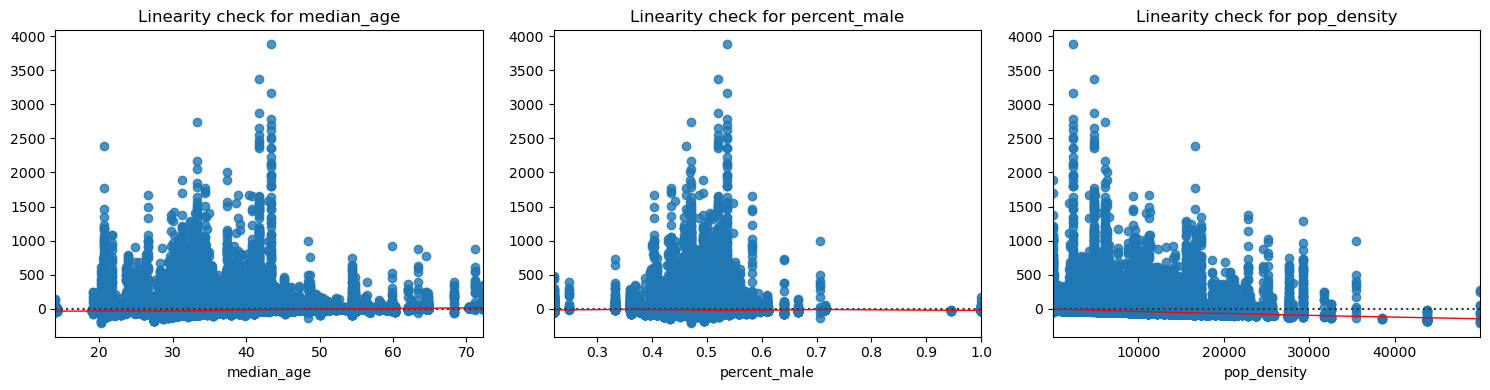

                            OLS Regression Results                            
Dep. Variable:         total_flow_log   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     4493.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:24:40   Log-Likelihood:            -1.9415e+05
No. Observations:              105918   AIC:                         3.883e+05
Df Residuals:                  105914   BIC:                         3.883e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8796      0.084     

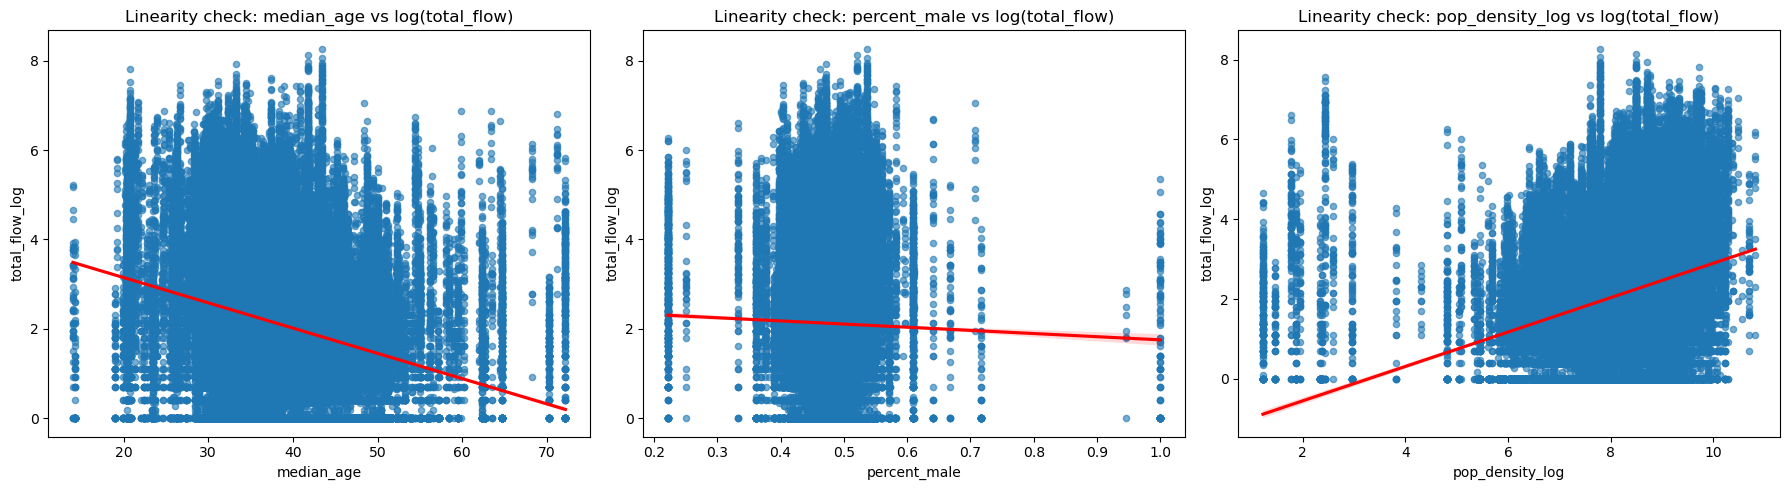

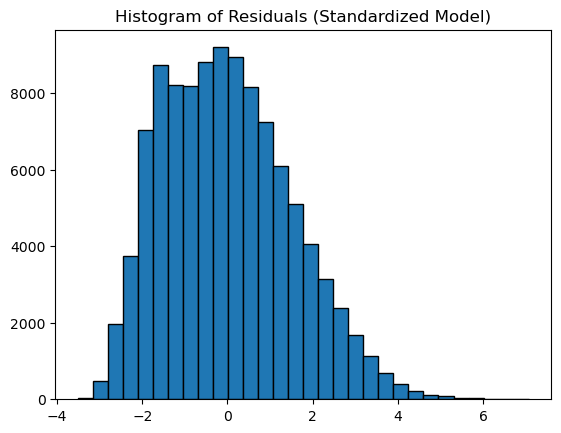

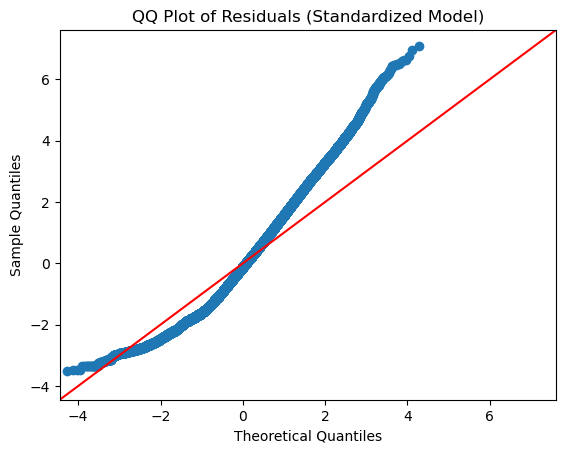

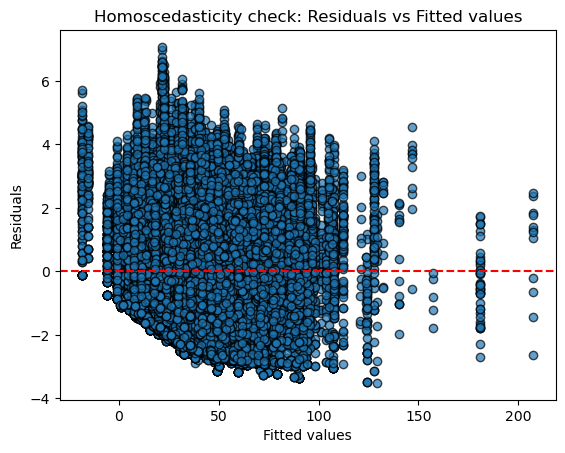

In [5]:
# For total_flow
# establish a mutiple linear regression model about Y1
X = df [['median_age', 'percent_male', 'pop_density']]
X = sm.add_constant(X)
Y1 = df['total_flow']
model_total = sm.OLS(Y1, X).fit()

# calculate the residuals and fitted values
residuals_total = model_total.resid
fitted_total = model_total.fittedvalues

# calculate the mean of independent variables respectively
means = df[['median_age', 'percent_male', 'pop_density']].mean().reset_index()
means.columns = ['Variable', 'Mean']
print(means)

# check the linearrity vs fitted values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, var in enumerate(['median_age', 'percent_male', 'pop_density']):
    sns.residplot(x=df[var], y=residuals_total, lowess=True, ax=axes[i],
                  line_kws={"color": "red", "lw": 1})
    axes[i].set_title(f"Linearity check for {var}")
plt.tight_layout()
plt.show()

# transform the the right-skewed variable
df["total_flow_log"] = np.log1p(df["total_flow"])
df["pop_density_log"] = np.log1p(df["pop_density"])

# establish a mutiple linear regression model about log(Y1) and log(pop_density)
X = sm.add_constant(df[["median_age", "percent_male", "pop_density_log"]])
Y1_log = df["total_flow_log"]
model_std_toal = sm.OLS(Y1_log, X).fit()
print(model_std_toal.summary())

# check the lineraity again
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot_toal = ["median_age", "percent_male", "pop_density_log"]
for i, var in enumerate(vars_to_plot_toal):
    sns.regplot(x=var, y="total_flow_log", data=df,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: {var} vs log(total_flow)")

plt.tight_layout()
plt.show()

# Z-score
df["median_age_z"] = (df["median_age"] - df["median_age"].mean()) / df["median_age"].std()
df["percent_male_z"] = (df["percent_male"] - df["percent_male"].mean()) / df["percent_male"].std()
df["pop_density_log_z"] = (df["pop_density_log"] - df["pop_density_log"].mean()) / df["pop_density_log"].std()

# test the normality of residuals vs fitted values
residuals_total = model_std_toal.resid
# histogram of residuals
plt.hist(residuals_total, bins=30, edgecolor='k')
plt.title("Histogram of Residuals (Standardized Model)")
plt.show()
# QQ plot
sm.qqplot(residuals_total, line='45')
plt.title("QQ Plot of Residuals (Standardized Model)")
plt.show()

# test homoscedasticity
plt.scatter(fitted_total, residuals_total, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity check: Residuals vs Fitted values")
plt.show()



3. Multiple Linear Congression (Model 2: Y2-average_flow, X1-Median_Age, X2-Percent_Male, X3-pop_density)3

       Variable         Mean
0    median_age    38.145254
1  percent_male     0.479577
2   pop_density  5383.398609


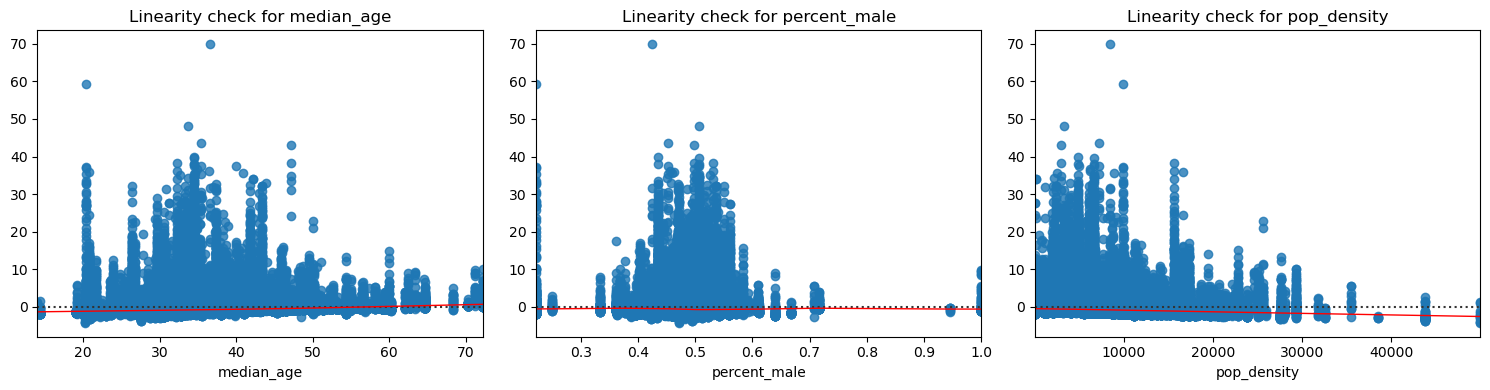

                            OLS Regression Results                            
Dep. Variable:       average_flow_log   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     2871.
Date:                Thu, 06 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:27:40   Log-Likelihood:                -90386.
No. Observations:              105918   AIC:                         1.808e+05
Df Residuals:                  105914   BIC:                         1.808e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0725      0.032     

In [ ]:
# For average_flow
# establish a mutiple linear regression model about Y2
X = df [['median_age', 'percent_male', 'pop_density']]
X = sm.add_constant(X)
Y2 = df['average_flow']
model_avg = sm.OLS(Y2, X).fit()

# calculate the residuals and fitted values
residuals_avg = model_avg.resid
fitted_avg = model_avg.fittedvalues

# calculate the mean of independent variables respectively
means = df[['median_age', 'percent_male', 'pop_density']].mean().reset_index()
means.columns = ['Variable', 'Mean']
print(means)

# check the linearrity vs fitted values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, var in enumerate(['median_age', 'percent_male', 'pop_density']):
    sns.residplot(x=df[var], y=residuals_avg, lowess=True, ax=axes[i],
                  line_kws={"color": "red", "lw": 1})
    axes[i].set_title(f"Linearity check for {var}")
plt.tight_layout()
plt.show()

# transform the the right-skewed variable
df["average_flow_log"] = np.log1p(df["average_flow"])
df["pop_density_log"] = np.log1p(df["pop_density"])

# establish a mutiple linear regression model about log(Y2) and log(pop_density)
X = sm.add_constant(df[["median_age", "percent_male", "pop_density_log"]])
Y2_log = df["average_flow_log"]
model_std_avg = sm.OLS(Y2_log, X).fit()
print(model_std_avg.summary())

# check the lineraity again
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vars_to_plot_avg = ["median_age", "percent_male", "pop_density_log"]
for i, var in enumerate(vars_to_plot_avg):
    sns.regplot(x=var, y="average_flow_log", data=df,
                ax=axes[i], scatter_kws={"s":20, "alpha":0.6},
                line_kws={"color":"red"})
    axes[i].set_title(f"Linearity check: {var} vs log(average_flow)")

plt.tight_layout()
plt.show()

# Z-score
df["median_age_z"] = (df["median_age"] - df["median_age"].mean()) / df["median_age"].std()
df["percent_male_z"] = (df["percent_male"] - df["percent_male"].mean()) / df["percent_male"].std()
df["pop_density_log_z"] = (df["pop_density_log"] - df["pop_density_log"].mean()) / df["pop_density_log"].std()

# test the normality of residuals vs fitted values
residuals_avg = model_std_avg.resid
# histogram of residuals
plt.hist(residuals_avg, bins=30, edgecolor='k')
plt.title("Histogram of Residuals (Standardized Model)")
plt.show()
# QQ plot
sm.qqplot(residuals_avg, line='45')
plt.title("QQ Plot of Residuals (Standardized Model)")
plt.show()

# test homoscedasticity
plt.scatter(fitted_avg, residuals_avg, edgecolor='k', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity check: Residuals vs Fitted values")
plt.show()




After processing the data and decide the analyses methods, the following is done:

**C. Relevant General Graphs**

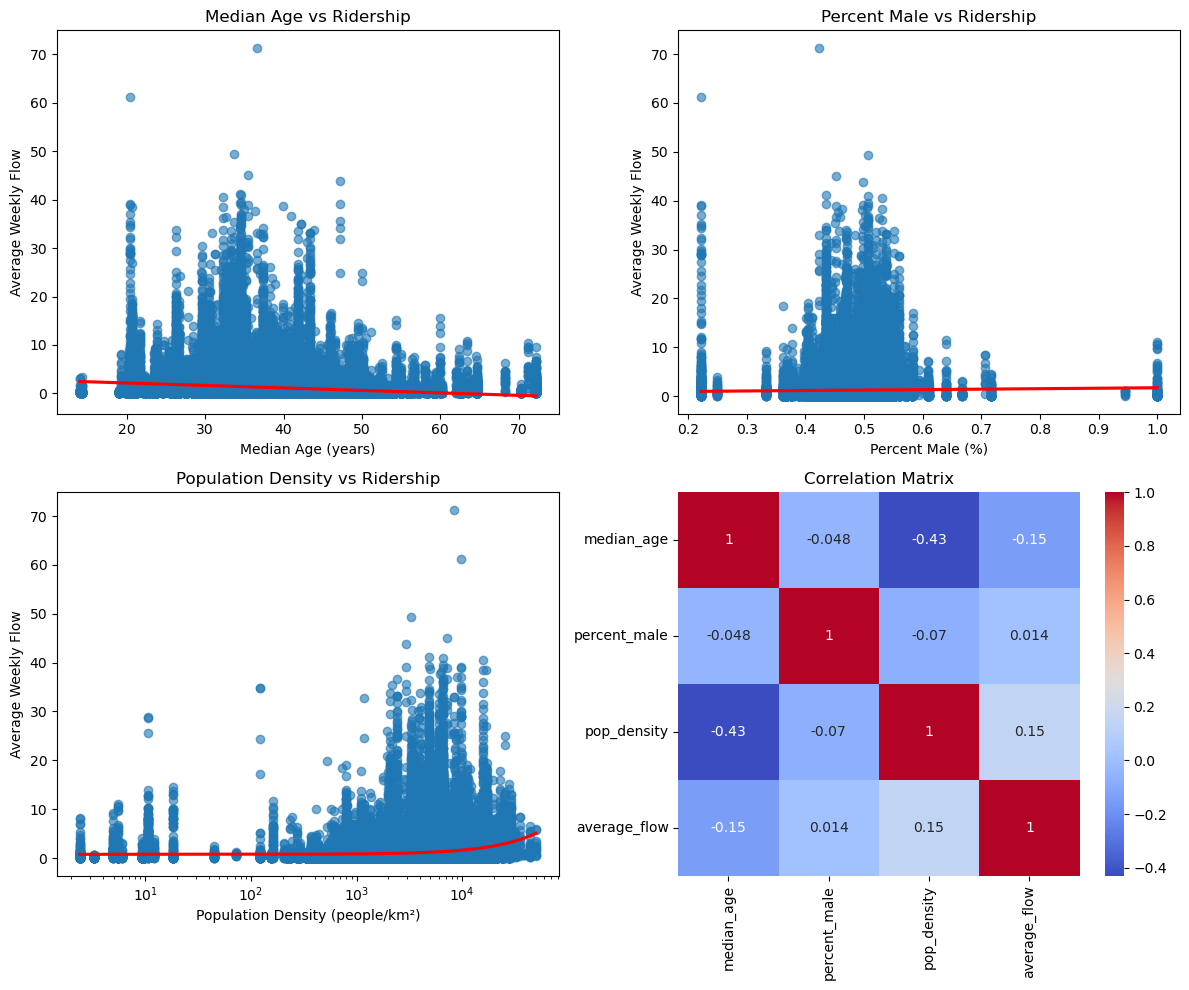

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Median Age vs Ridership
sns.regplot(
    ax=axes[0, 0],
    x='median_age',
    y='average_flow',
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
axes[0, 0].set_title('Median Age vs Ridership')
axes[0, 0].set_xlabel('Median Age (years)')
axes[0, 0].set_ylabel('Average Weekly Flow')

# 2. Percent Male vs Ridership
sns.regplot(
    ax=axes[0, 1],
    x='percent_male',
    y='average_flow',
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
axes[0, 1].set_title('Percent Male vs Ridership')
axes[0, 1].set_xlabel('Percent Male (%)')
axes[0, 1].set_ylabel('Average Weekly Flow')

# 3. Population Density vs Ridership 
sns.regplot(
    ax=axes[1, 0],
    x='pop_density',
    y='average_flow',
    data=df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('Population Density vs Ridership')
axes[1, 0].set_xlabel('Population Density (people/km²)')
axes[1, 0].set_ylabel('Average Weekly Flow')

# 4. Correlation Matrix
correlation = df[['median_age', 'percent_male', 'pop_density', 'average_flow']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

The general graphs above shows scatter plots that are used to examine the relationship between demographic variables and bus ridership because they clearly display how two continuous variables relate to one another. Each point represents a bus stop, showing how demographic characteristics (such as median age, gender distribution, or population density) correspond to the level of bus usage. The red regression line visualize the general trend or direction of the relationship.

1. The first scatter plot, showing median age versus ridership, reveals a slightly negative trend, areas with higher median ages tend to have lower average bus ridership.
2. The second scatter plot, comparing percent male and ridership, shows no clear pattern, suggesting that gender distribution has little influence on how often people use the bus.
3. The third graph, which compares population density to ridership, displays a clear upward trend, especially on the log scale indicating that bus stops located in denser neighborhoods have higher passenger flows.

4. A heatmap is used to summarize and compare correlations between all variables at once. The heatmap visually highlights that population density has the strongest positive correlation with bus ridership (r ≈ 0.15), while median age and percent male show weak or negative correlations.

Overall, the graphs show that population density is the key demographic factor influencing bus ridership in Boston, while age and gender play only minor roles.

**Analysis about how to distribute the median age for the population using boxplot?**

A boxplot is chosen to visualize the relationship between bus ridership and the median age of local block groups. This method provides a clear summary of the data distribution by displaying the median, interquartile range, and potential outliers for each age group. It allows for straightforward comparison between different demographic categories, making it easy to identify which median age ranges are associated with higher or lower bus ridership levels. Furthermore, the boxplot does not assume a normal distribution of data, which is beneficial since ridership values often vary widely and may be skewed. Overall, the boxplot offers an efficient and interpretable way to explore demographic influences on public transport usage.

The data contains median_age as a numerical value per bus stop. 
To use this in a boxplot analysis, this is divide it into groups (bins) so that the distribution of average_flow (bus use) per age category is seen.

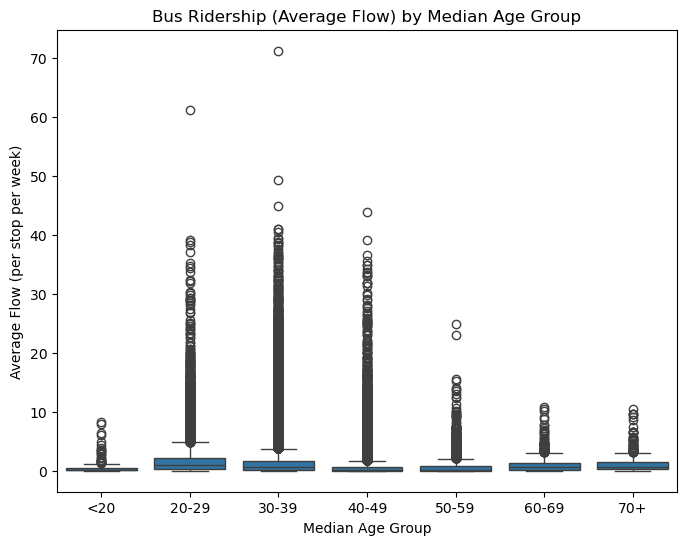

In [ ]:
# Step 1: Create age bins, the median ages can be group into meaningful intervals (for example, based on census or demographic standards):
bins = [0, 20, 30, 40, 50, 60, 70, 100]  # age ranges
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['age_group'] = pd.cut(df['median_age'], bins=bins, labels=labels, right=False) 

# Step 2: Create the boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x='age_group', y='average_flow', data=df)
plt.title('Bus Ridership (Average Flow) by Median Age Group')
plt.xlabel('Median Age Group')
plt.ylabel('Average Flow (per stop per week)')
plt.show()

The boxplot above shows that:
- Bus stops in younger neighborhoods (especially 20-29 and 30-39) have higher average passenger flow.
- Ridership tends to decrease gradually with age, meaning areas with older populations generally have less bus usage.
- A few extreme outliers exist stops with exceptionally high ridership which may correspond to key transport nodes or transfer points.

**Analysis gender distribution (percent_male)**

This variable represents the percentage of men in a block group (between 0 and 1).
This can be converted into categories per 10% or 5%, so that the impact on bus use can be seen

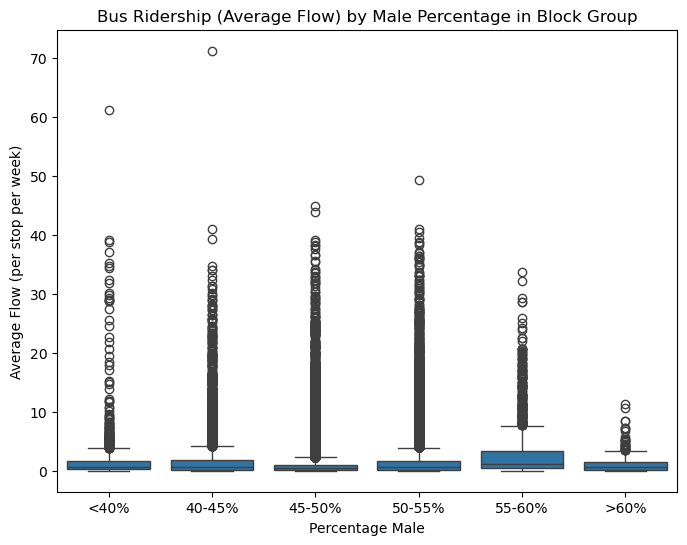

In [ ]:
# Step 1: Create categories in 10% increments
bins = [0, 0.4, 0.45, 0.5, 0.55, 0.6, 1]
labels = ['<40%', '40-45%', '45-50%', '50-55%', '55-60%', '>60%']

df['gender_group'] = pd.cut(df['percent_male'], bins=bins, labels=labels, right=False)

# Step 2: Boxplot of bus use by gender distribution
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender_group', y='average_flow', data=df)
plt.title('Bus Ridership (Average Flow) by Male Percentage in Block Group')
plt.xlabel('Percentage Male')
plt.ylabel('Average Flow (per stop per week)')
plt.show()

**Analysis Population density**

This variable is usually skewed (some areas are very densely populated).
Therefore, we use a log transformation or quantile groups to ensure fair comparisons.

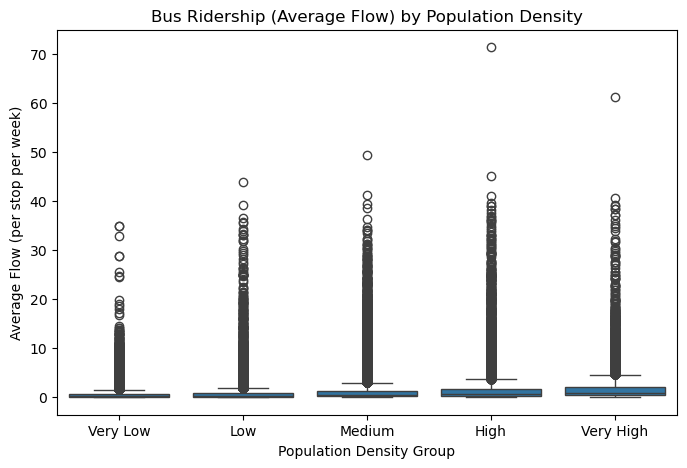

In [ ]:
# add log-transformation
df['log_density'] = np.log(df['pop_density'] + 1)  # +1 om log(0) te voorkomen

# Divide into 5 equal quantile groups
df['density_group'] = pd.qcut(df['log_density'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='density_group', y='average_flow', data=df)
plt.title('Bus Ridership (Average Flow) by Population Density')
plt.xlabel('Population Density Group')
plt.ylabel('Average Flow (per stop per week)')
plt.show()

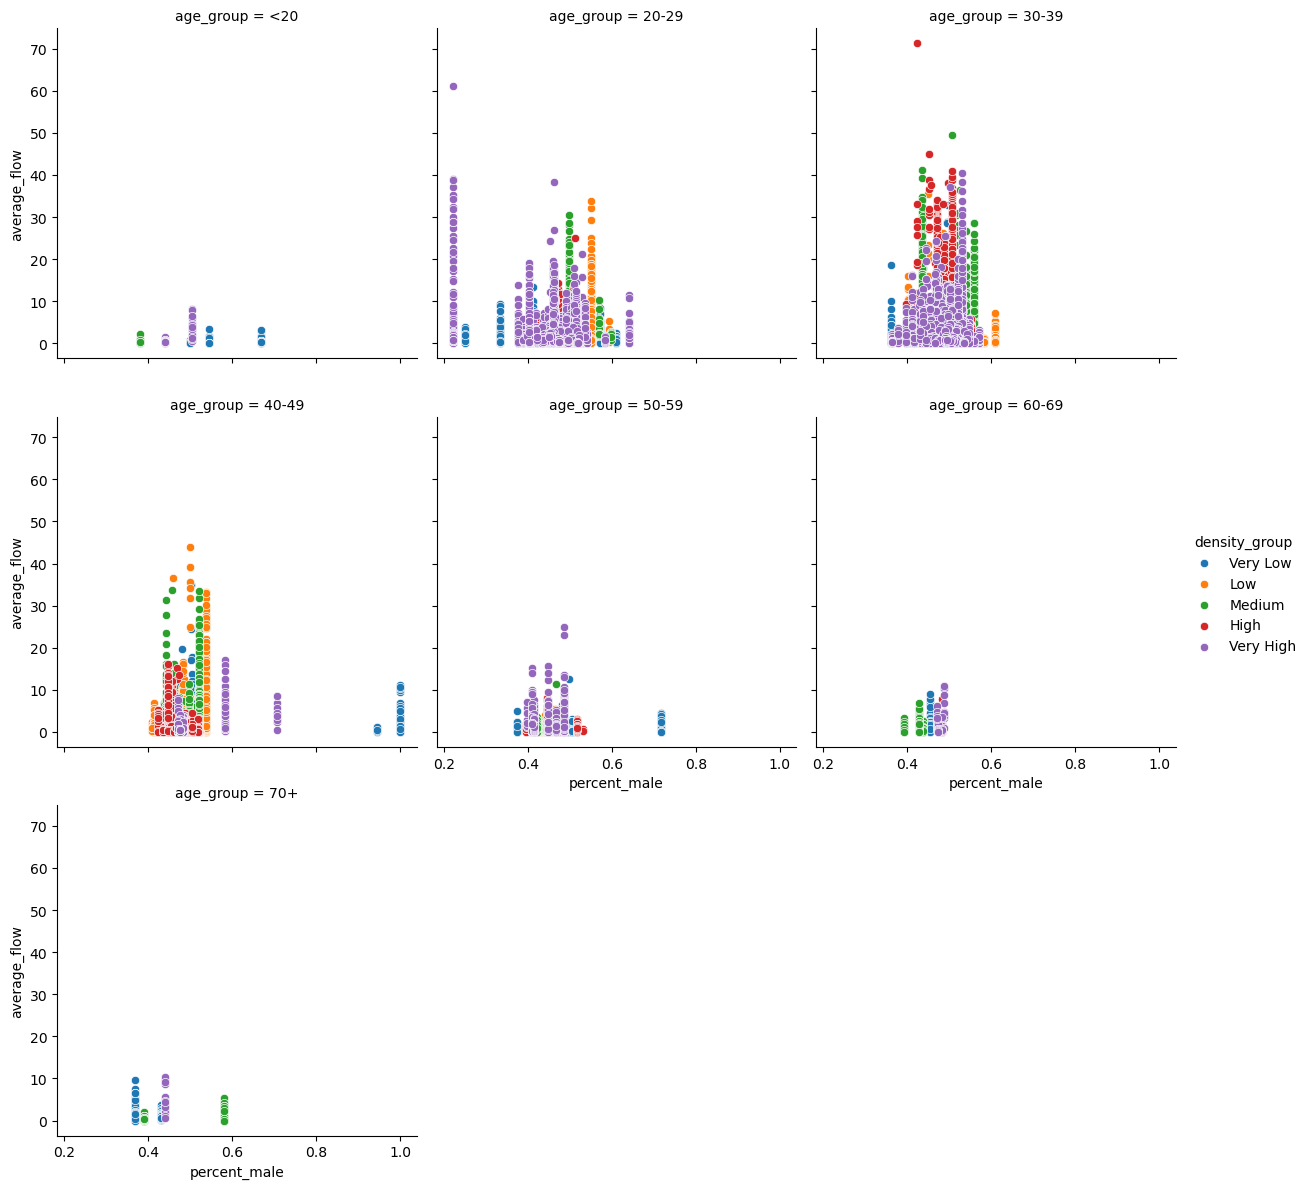

In [ ]:
# Combine in one overview
g = sns.FacetGrid(df, col='age_group', hue='density_group', col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x='percent_male', y='average_flow')
g.add_legend()
plt.show()

# 7. Conclusion
.........

# 8. Discussion
.......

# 9. References
.......


In [ ]:
import pandas as pd
import geopandas as gpd
import plotly.graph_objects as go
from shapely import wkt
from shapely.geometry import LineString, MultiLineString, Point

# Load Stops
stops_info = pd.read_csv("TIL6022datageo.csv")

# Parse WKT(Well-Known Text) geometry into Shapely Points
stops_info['geometry'] = stops_info['geometry'].apply(wkt.loads)

# Create a GeoDataFrame for stops with (CRS:Coordinate Reference System)
#EPSG Geodetic Parameter Dataset, which is a giant registry of CRS definitions
stops_gdf = gpd.GeoDataFrame(
    stops_info, 
    geometry='geometry',
    crs='EPSG:26986'  # Massachusetts State Plane
)

# Reproject stops to WGS84[standard GPS mapping] (lat/lon)
stops_gdf = stops_gdf.to_crs(epsg=4326)

# Extract lat/lon from the reprojected points
stops_gdf['lon'] = stops_gdf['geometry'].apply(lambda p: p.x)
stops_gdf['lat'] = stops_gdf['geometry'].apply(lambda p: p.y)

#Filter columns for hover
hover_cols = [col for col in stops_info.columns if not col.startswith('Unnamed') and col != 'geometry']

#Load Routes
routes = gpd.read_file("MBTABUSROUTES_ARC.shp")

# If CRS is not set, manually assign EPSG:26986
if routes.crs is None:
    routes = routes.set_crs(epsg=26986)

# Reproject to WGS84 (EPSG:4326) for lat/lon
routes = routes.to_crs(epsg=4326)

#Extract coordinates from LineString / MultiLineString
def get_coords(geom):
    lons, lats = [], []
    if isinstance(geom, LineString):
        x, y = geom.xy
        lons.extend(x)
        lats.extend(y)
    elif isinstance(geom, MultiLineString):
        for line in geom.geoms:
            x, y = line.xy
            lons.extend(x)
            lats.extend(y)
    return lons, lats

# Create Plotly figure
fig = go.Figure()

# Add routes
for _, row in routes.iterrows():
    lons, lats = get_coords(row.geometry)
    fig.add_trace(go.Scattermapbox(
        lon=lons,
        lat=lats,
        mode='lines',
        line=dict(width=2, color='blue'),
        name=row.get('ROUTE_NAME', 'Route'),
        showlegend=False
    ))

# Add stops
fig.add_trace(go.Scattermapbox(
    lon=stops_gdf['lon'].tolist(),
    lat=stops_gdf['lat'].tolist(),
    mode='markers',
    marker=dict(size=6, color='red'),
    customdata=stops_info[hover_cols].values,
    hovertemplate='<br>'.join([f'<b>{col}</b>: %{{customdata[{i}]}}' for i, col in enumerate(hover_cols)]) + '<extra></extra>',
    name='Stops',
    showlegend=True
))

# fix Layout
# Compute map center based on reprojected stops
center_lat = stops_gdf['lat'].mean()
center_lon = stops_gdf['lon'].mean()

fig.update_layout(
    mapbox_style="open-street-map",
    mapbox=dict(
        zoom=10,
        center=dict(lat=center_lat, lon=center_lon)
    ),
    height=700,
    title="MBTA Bus Routes and Stops",
    margin={"r":0,"t":30,"l":0,"b":0}
)

fig.show()

c:\Users\mulha\anaconda3\Lib\site-packages\pyogrio\raw.py:198: UserWarning:

Measured (M) geometry types are not supported. Original type 'Measured LineString' is converted to 'LineString'

